In [1]:
from pathlib import Path
import sys
import random
import pandas as pd
import torch
from PIL import Image
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from torchvision import transforms
from torch.utils.data import DataLoader


current_dir = Path.cwd()
if (current_dir / "data").exists():
    PROJECT_ROOT = current_dir
else:
    PROJECT_ROOT = current_dir.parent


sys.path.append(str(PROJECT_ROOT))
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw" / "pigreid"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed" / "pigreid_4992"
METADATA_DIR = PROJECT_ROOT / "data" / "metadata"
RUNS_DIR = PROJECT_ROOT / "runs"
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
METADATA_DIR.mkdir(parents=True, exist_ok=True)
RUNS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

d:\anaconda\Lib\site-packages\sklearn\utils\_param_validation.py:14: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.1)
  from scipy.sparse import csr_array, issparse


In [2]:
SELECTED_IDENTITIES = [
    "G8_78",
    "G8_79",
    "G8_82",
    "G8_86",
    "G8_87",
    "G8_88",
    "G8_90",
    "G12_54",
    "G12_57",
    "G12_61",
    "G12_62",
    "G12_66",
]

IMAGES_PER_IDENTITY = 416
IMAGE_SIZE = 224
TEST_SIZE = 0.20
QUERY_IMAGES_PER_ID = 20
INITIAL_LABELED_FRACTION = 0.10
AL_BUDGET = 1000
EPOCHS = 15
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
EMBEDDING_DIM = 256


subset_rows = []
for identity_id in SELECTED_IDENTITIES:
    identity_dir = RAW_DATA_DIR / identity_id

    image_paths = [
        path for path in identity_dir.iterdir()
        if path.is_file() and path.suffix.lower() == ".png"
    ]
    
    image_paths = sorted(image_paths, key=lambda path: path.name)
    
    if len(image_paths) < IMAGES_PER_IDENTITY:
        raise ValueError(f"{identity_id}: only {len(image_paths)} images, need {IMAGES_PER_IDENTITY}")
    
    selected_indices = [
        round(index * (len(image_paths) - 1) / (IMAGES_PER_IDENTITY - 1))
        for index in range(IMAGES_PER_IDENTITY)
    ]
    
    selected_images = [image_paths[index] for index in selected_indices]
    
    for image_path in selected_images:
        subset_rows.append({
            "original_path": str(image_path),
            "identity_id": identity_id,
            "file_name": image_path.name
        })

subset_df = pd.DataFrame(subset_rows)

print("Subset size:", len(subset_df))
display(subset_df["identity_id"].value_counts())

Subset size: 4992


identity_id
G8_78     416
G8_79     416
G8_82     416
G8_86     416
G8_87     416
G8_88     416
G8_90     416
G12_54    416
G12_57    416
G12_61    416
G12_62    416
G12_66    416
Name: count, dtype: int64

In [4]:
processed_rows = []

for row in tqdm(subset_df.itertuples(index=False), total=len(subset_df)):
    src_path = Path(row.original_path)
    identity_id = row.identity_id
    dst_identity_dir = PROCESSED_DATA_DIR / identity_id
    dst_identity_dir.mkdir(parents=True, exist_ok=True)
    dst_file_name = src_path.stem + ".jpg"
    dst_path = dst_identity_dir / dst_file_name
    
    if not dst_path.exists():
        image = Image.open(src_path)
        image = image.convert("RGB")
        image = image.resize((IMAGE_SIZE, IMAGE_SIZE), Image.Resampling.LANCZOS)
        image.save(dst_path, quality=95)
    
    processed_rows.append({
        "image_path": str(dst_path),
        "identity_id": identity_id,
        "original_path": str(src_path),
        "file_name": dst_file_name
    })


metadata_df = pd.DataFrame(processed_rows)
metadata_path = METADATA_DIR / "metadata_4992.csv"
metadata_df.to_csv(metadata_path, index=False)

display(metadata_df.head())
print("Processed images:", len(metadata_df))
print("Saved metadata:", metadata_path)
display(metadata_df["identity_id"].value_counts())

  0%|          | 0/4992 [00:00<?, ?it/s]

,image_path,identity_id,original_path,file_name
0,d:\farm_project\data\processed\pigreid_4992\G8...,G8_78,d:\farm_project\data\raw\pigreid\G8_78\Basler_...,Basler_acA4112-20uc__40331001__20240716_091921...
1,d:\farm_project\data\processed\pigreid_4992\G8...,G8_78,d:\farm_project\data\raw\pigreid\G8_78\Basler_...,Basler_acA4112-20uc__40331001__20240716_091921...
2,d:\farm_project\data\processed\pigreid_4992\G8...,G8_78,d:\farm_project\data\raw\pigreid\G8_78\Basler_...,Basler_acA4112-20uc__40331001__20240716_091921...
3,d:\farm_project\data\processed\pigreid_4992\G8...,G8_78,d:\farm_project\data\raw\pigreid\G8_78\Basler_...,Basler_acA4112-20uc__40331001__20240716_091921...
4,d:\farm_project\data\processed\pigreid_4992\G8...,G8_78,d:\farm_project\data\raw\pigreid\G8_78\Basler_...,Basler_acA4112-20uc__40331001__20240716_091921...


Processed images: 4992
Saved metadata: d:\farm_project\data\metadata\metadata_4992.csv


identity_id
G8_78     416
G8_79     416
G8_82     416
G8_86     416
G8_87     416
G8_88     416
G8_90     416
G12_54    416
G12_57    416
G12_61    416
G12_62    416
G12_66    416
Name: count, dtype: int64

In [5]:
split_parts = []


for identity_id, group_df in metadata_df.groupby("identity_id"):
    
    group_df = group_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
    
    train_df, test_df = train_test_split(
        group_df,
        test_size=TEST_SIZE,
        random_state=RANDOM_SEED,
        shuffle=True
    )
    
    test_df = test_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
    
    query_df = test_df.iloc[:QUERY_IMAGES_PER_ID].copy()
    gallery_df = test_df.iloc[QUERY_IMAGES_PER_ID:].copy()
    
    train_df = train_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
    
    n_initial_labeled = max(2, int(len(train_df) * INITIAL_LABELED_FRACTION))
    
    initial_labeled_df = train_df.iloc[:n_initial_labeled].copy()
    
    unlabeled_df = train_df.iloc[n_initial_labeled:].copy()
    
    initial_labeled_df["split"] = "train_pool"
    
    initial_labeled_df["pool_status"] = "initial_labeled"
    
    initial_labeled_df["is_labeled"] = True
    
    unlabeled_df["split"] = "train_pool"
    
    unlabeled_df["pool_status"] = "unlabeled"
    
    unlabeled_df["is_labeled"] = False
    
    query_df["split"] = "test"
    
    query_df["pool_status"] = "query"
    
    query_df["is_labeled"] = True
    
    gallery_df["split"] = "test"
    
    gallery_df["pool_status"] = "gallery"
    
    gallery_df["is_labeled"] = True
    
    split_parts.append(initial_labeled_df)
    
    split_parts.append(unlabeled_df)
    
    split_parts.append(query_df)
    
    split_parts.append(gallery_df)


split_df = pd.concat(split_parts, ignore_index=True)

identity_ids = sorted(split_df["identity_id"].unique())

identity_to_label = {
    identity_id: index
    for index, identity_id in enumerate(identity_ids)
}

split_df["label_idx"] = split_df["identity_id"].map(identity_to_label)

num_classes = len(identity_to_label)

splits_path = METADATA_DIR / "splits_4992.csv"

split_df.to_csv(splits_path, index=False)

In [6]:
from src.dataset import PigReIDDataset
from src.evaluation import extract_embeddings, compute_rank1_map

train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

query_df = split_df[split_df["pool_status"] == "query"].copy()

gallery_df = split_df[split_df["pool_status"] == "gallery"].copy()

query_dataset = PigReIDDataset(
    dataframe=query_df,
    transform=train_transform
)

gallery_dataset = PigReIDDataset(
    dataframe=gallery_df,
    transform=train_transform
)

query_loader = DataLoader(
    query_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

gallery_loader = DataLoader(
    gallery_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

def evaluate_model(model):
    query_embeddings, query_labels, query_identity_ids, query_image_paths = extract_embeddings(
        model=model,
        dataloader=query_loader,
        device=device
    )
    gallery_embeddings, gallery_labels, gallery_identity_ids, gallery_image_paths = extract_embeddings(
        model=model,
        dataloader=gallery_loader,
        device=device
    )
    metrics = compute_rank1_map(
        query_embeddings=query_embeddings,
        query_labels=query_labels,
        gallery_embeddings=gallery_embeddings,
        gallery_labels=gallery_labels
    )
    
    return metrics

print("Query size:", len(query_dataset))

print("Gallery size:", len(gallery_dataset))

Query size: 240
Gallery size: 768


In [9]:
from src.training import train_reid_model

initial_train_df = split_df[split_df["pool_status"] == "initial_labeled"].copy()
print("Initial train size:", len(initial_train_df))

model_initial, history_initial = train_reid_model(
    train_df=initial_train_df,
    train_transform=train_transform,
    num_classes=num_classes,
    device=device,
    epochs=50,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    embedding_dim=EMBEDDING_DIM,
    seed=RANDOM_SEED
)

metrics_initial = evaluate_model(model_initial)

print(f"Initial Rank-1: {metrics_initial['rank1']:.4f}")
print(f"Initial mAP: {metrics_initial['mAP']:.4f}")

Initial train size: 396


Epoch 1/50:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 1: total_loss=2.7536, ce_loss=2.4642, triplet_loss=0.2894


Epoch 2/50:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 2: total_loss=2.6965, ce_loss=2.4040, triplet_loss=0.2925


...

Epoch 48: total_loss=1.5078, ce_loss=1.4882, triplet_loss=0.0196


Epoch 49/50:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 49: total_loss=1.4718, ce_loss=1.4715, triplet_loss=0.0003


Epoch 50/50:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 50: total_loss=1.4671, ce_loss=1.4568, triplet_loss=0.0103
Initial Rank-1: 0.4583
Initial mAP: 0.3288


In [10]:
from src.active_learning import core_set_selection


labeled_df = split_df[split_df["pool_status"] == "initial_labeled"].copy()

unlabeled_df = split_df[split_df["pool_status"] == "unlabeled"].copy()

labeled_dataset = PigReIDDataset(
    dataframe=labeled_df,
    transform=train_transform
)

unlabeled_dataset = PigReIDDataset(
    dataframe=unlabeled_df,
    transform=train_transform
)

labeled_loader = DataLoader(
    labeled_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

unlabeled_loader = DataLoader(
    unlabeled_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

labeled_embeddings, labeled_labels, labeled_identity_ids, labeled_image_paths = extract_embeddings(
    model=model_initial,
    dataloader=labeled_loader,
    device=device
)

unlabeled_embeddings, unlabeled_labels, unlabeled_identity_ids, unlabeled_image_paths = extract_embeddings(
    model=model_initial,
    dataloader=unlabeled_loader,
    device=device
)

selected_indices = core_set_selection(
    labeled_embeddings=labeled_embeddings,
    unlabeled_embeddings=unlabeled_embeddings,
    budget=AL_BUDGET
)

selected_al_df = unlabeled_df.iloc[selected_indices].copy()

selected_al_df["pool_status"] = "active_labeled"

selected_al_df["is_labeled"] = True

al_train_df = pd.concat(
    [initial_train_df, selected_al_df],
    ignore_index=True
)

print("AL selected:", len(selected_al_df))

print("AL train size:", len(al_train_df))

display(al_train_df["identity_id"].value_counts())

AL selected: 1000
AL train size: 1396


identity_id
G12_62    178
G12_66    143
G12_54    135
G12_57    131
G8_78     124
G8_87     116
G8_82     110
G12_61    103
G8_86     101
G8_79     100
G8_88      78
G8_90      77
Name: count, dtype: int64

In [11]:
model_al, history_al = train_reid_model(
    train_df=al_train_df,
    train_transform=train_transform,
    num_classes=num_classes,
    device=device,
    epochs=50,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    embedding_dim=EMBEDDING_DIM,
    seed=RANDOM_SEED
)

metrics_al = evaluate_model(model_al)

print(f"Core-set AL Rank-1: {metrics_al['rank1']:.4f}")
print(f"Core-set AL mAP: {metrics_al['mAP']:.4f}")

Epoch 1/50:   0%|          | 0/44 [00:00<?, ?it/s]

Epoch 1: total_loss=2.7506, ce_loss=2.4397, triplet_loss=0.3108


Epoch 2/50:   0%|          | 0/44 [00:00<?, ?it/s]

Epoch 2: total_loss=2.6253, ce_loss=2.3323, triplet_loss=0.2930


Epoch 3/50:   0%|          | 0/44 [00:00<?, ?it/s]

...

Epoch 48: total_loss=0.5889, ce_loss=0.5545, triplet_loss=0.0344


Epoch 49/50:   0%|          | 0/44 [00:00<?, ?it/s]

Epoch 49: total_loss=0.5496, ce_loss=0.5293, triplet_loss=0.0204


Epoch 50/50:   0%|          | 0/44 [00:00<?, ?it/s]

Epoch 50: total_loss=0.5791, ce_loss=0.5205, triplet_loss=0.0586
Core-set AL Rank-1: 0.7542
Core-set AL mAP: 0.6360


In [12]:
results_df = pd.DataFrame([
    {
        "experiment": "Initial",
        "train_size": len(initial_train_df),
        "rank1": metrics_initial["rank1"],
        "mAP": metrics_initial["mAP"]
    },
    {
        "experiment": "Core-set AL",
        "train_size": len(al_train_df),
        "rank1": metrics_al["rank1"],
        "mAP": metrics_al["mAP"]
    }
])

results_path = RUNS_DIR / "larger_al_experiment_results.csv"

results_df.to_csv(results_path, index=False)

display(results_df)
print("Saved results:", results_path)

,experiment,train_size,rank1,mAP
0,Initial,396,0.458333,0.328756
1,Core-set AL,1396,0.754167,0.635979


Saved results: d:\farm_project\runs\larger_al_experiment_results.csv


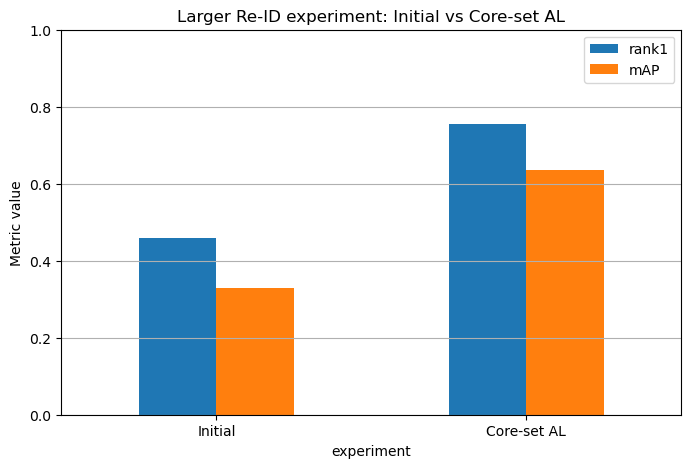

In [13]:
import matplotlib.pyplot as plt

plot_df = results_df.set_index("experiment")[["rank1", "mAP"]]

ax = plot_df.plot(
    kind="bar",
    figsize=(8, 5),
    rot=0
)

ax.set_title("Larger Re-ID experiment: Initial vs Core-set AL")
ax.set_ylabel("Metric value")
ax.set_ylim(0, 1)
ax.grid(axis="y")
plt.show()